In [2]:
!sudo apt-get install -y tesseract-ocr


!pip install pytesseract opencv-python Pillow


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [4]:
from google.colab import files
uploaded = files.upload()


Saving hello.jpg to hello.jpg


=== OCR OUTPUT ===
Hello



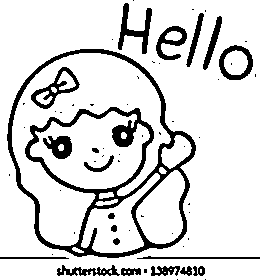

In [6]:
import cv2
import pytesseract
import numpy as np
from google.colab.patches import cv2_imshow


pytesseract.pytesseract.tesseract_cmd = r"/usr/bin/tesseract"

MODE = "OCR"


img = cv2.imread("hello.jpg")

if img is None:
    print("Image not found. Upload again or check filename.")
else:
    (h, w) = img.shape[:2]

    if MODE == "OCR":

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.adaptiveThreshold(
            blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 11, 2
        )


        custom_config = r'--oem 3 --psm 6'
        text = pytesseract.image_to_string(thresh, config=custom_config)

        print("=== OCR OUTPUT ===")
        print(text)


        cv2_imshow(thresh)

    elif MODE == "DETECTION":

        net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "mobilenet_ssd.caffemodel")


        blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)),
                                     0.007843, (300, 300), 127.5)
        net.setInput(blob)
        detections = net.forward()

        for i in range(detections.shape[2]):
            confidence = detections[0, 0, i, 2]
            if confidence > 0.80:
                box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
                (startX, startY, endX, endY) = box.astype("int")

                label = f"Object {i}: {confidence*100:.2f}%"
                cv2.rectangle(img, (startX, startY), (endX, endY), (0, 255, 0), 2)
                cv2.putText(img, label, (startX, startY-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        print("=== OBJECT DETECTION OUTPUT ===")
        cv2_imshow(img)
